# 06 — ZBP Sector Panel Builder

Builds `did_zbp_sector_panel.csv` used by `R/10_did_zbp_sector.R`.

## Purpose
Tests whether flood-exposed ZIPs show different sector composition trajectories
compared to control ZIPs, using ZBP detail (NAICS breakdown) data.

## Steps
1. Load ZBP sector detail from `data/raw/census_zbp/zbp_tx_sectors.parquet`
2. Filter to the 13 study ZIPs (same as notebook 03)
3. Merge NFIP treatment assignment (same thresholds as notebook 03)
4. Pivot sectors wide: `construction_emp`, `retail_emp`, `foodservice_emp`
5. Merge total employment from `zbp_tx_zips.parquet` for share computation
6. Export `data/processed/panels/did_zbp_sector_panel.csv`

## Design Notes
- Same 4 treated / 9 control ZIPs as R/03_did_zbp.R
- Pre-period 1994–1998; post-period 1999–2020
- NAICS available from 1998; 1994–1997 use SIC (mapped in `census_zbp.py`)
- Primary outcomes: log sector employment, sector employment share
- ZBP suppresses employment more heavily in detail files than totals

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.utils.file_io import load_parquet
from src.utils.logging_setup import get_logger

log = get_logger('06_zbp_sector_panel')

DATA_DIR = Path('../data')
RAW_DIR  = DATA_DIR / 'raw'
PROC_DIR = DATA_DIR / 'processed' / 'panels'
FIG_DIR  = DATA_DIR / 'results' / 'figures'
PROC_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load ZBP Sector Detail

In [2]:
sector_path = RAW_DIR / 'census_zbp' / 'zbp_tx_sectors.parquet'

if not sector_path.exists():
    raise FileNotFoundError(
        f'ZBP sector detail not found: {sector_path}\n'
        'Run: python -c "from src.acquire.census_zbp import run_detail; run_detail(force=True)"'
    )

sectors = load_parquet(sector_path)
sectors['zip'] = sectors['zip'].astype(str).str.zfill(5)
sectors['year'] = sectors['year'].astype(int)
for c in ['estab', 'emp_est']:
    if c in sectors.columns:
        sectors[c] = pd.to_numeric(sectors[c], errors='coerce').fillna(0)

print(f'Sector detail: {sectors.shape}')
print(f'Columns: {list(sectors.columns)}')
print(f'Sectors: {sorted(sectors["sector"].unique())}')
print(f'Years: {sectors["year"].min()}–{sectors["year"].max()}')
print(f'ZIPs: {sectors["zip"].nunique()}')
sectors.head(10)

Sector detail: (146461, 5)
Columns: ['zip', 'year', 'sector', 'estab', 'emp_est']
Sectors: ['construction', 'foodservice', 'retail']
Years: 1994–2020
ZIPs: 2515


,zip,year,sector,estab,emp_est
0,75001,1994,construction,20,315.0
1,75001,1994,foodservice,10,321.5
2,75001,1994,retail,54,690.5
3,75002,1994,construction,98,902.0
4,75002,1994,foodservice,19,408.0
5,75002,1994,retail,131,1844.0
6,75006,1994,construction,258,4878.0
7,75006,1994,foodservice,92,1837.5
8,75006,1994,retail,548,10294.5
9,75007,1994,construction,78,791.0


## 2. NFIP Treatment Assignment (same as notebook 03)

In [3]:
# Study ZIPs — same 13 as notebook 03 / R/03_did_zbp.R
COMAL_ZIPS   = ['78130', '78131', '78132', '78133', '78163', '78266', '78070']
CONTROL_ZIPS = ['78006', '78013', '78015', '78610', '78620', '78640']
ALL_ZIPS     = COMAL_ZIPS + CONTROL_ZIPS

# NFIP treatment (same thresholds as notebook 03)
NFIP_TREAT = {
    '78130': {'treated': 1, 'nfip_total_paid': 17027459},
    '78131': {'treated': 1, 'nfip_total_paid':  1022178},
    '78132': {'treated': 1, 'nfip_total_paid':  2572673},
    '78163': {'treated': 1, 'nfip_total_paid':  1682562},
    '78133': {'treated': 0, 'nfip_total_paid':   127157},
    '78266': {'treated': 0, 'nfip_total_paid':   106881},
    '78070': {'treated': 0, 'nfip_total_paid':     7065},
}

treat_df = pd.DataFrame([
    {'zip': z, 'treated': v['treated'],
     'intensity': np.log1p(v['nfip_total_paid']),
     'nfip_total_paid': v['nfip_total_paid']}
    for z, v in NFIP_TREAT.items()
])
# Adjacent control ZIPs get zeros
for z in CONTROL_ZIPS:
    treat_df = pd.concat([treat_df, pd.DataFrame([{
        'zip': z, 'treated': 0, 'intensity': 0, 'nfip_total_paid': 0
    }])], ignore_index=True)

print(treat_df.sort_values('nfip_total_paid', ascending=False).to_string(index=False))

  zip  treated  intensity  nfip_total_paid
78130        1  16.650338         17027459
78132        1  14.760456          2572673
78163        1  14.335829          1682562
78131        1  13.837447          1022178
78133        0  11.753186           127157
78266        0  11.579481           106881
78070        0   8.863050             7065
78006        0   0.000000                0
78013        0   0.000000                0
78015        0   0.000000                0
78610        0   0.000000                0
78620        0   0.000000                0
78640        0   0.000000                0


## 3. Filter to Study ZIPs and Pivot Sectors Wide

In [4]:
# Filter to study ZIPs
df = sectors[sectors['zip'].isin(ALL_ZIPS)].copy()

print(f'Study ZIP rows: {len(df)}')
print(f'Year × ZIP × sector coverage:')
print(df.groupby(['zip', 'sector'])['year'].agg(['min', 'max', 'count']).to_string())

Study ZIP rows: 1045
Year × ZIP × sector coverage:
                     min   max  count
zip   sector                         
78006 construction  1994  2020     27
      foodservice   1994  2020     27
      retail        1994  2020     27
78013 construction  1994  2020     27
      foodservice   1994  2020     27
      retail        1994  2020     27
78015 construction  1994  2020     27
      foodservice   1995  2020     26
      retail        1994  2020     27
78070 construction  1994  2020     27
      foodservice   1994  2020     27
      retail        1994  2020     27
78130 construction  1994  2020     27
      foodservice   1994  2020     27
      retail        1994  2020     27
78131 construction  1994  2020     27
      foodservice   1994  2020     26
      retail        1994  2016     21
78132 construction  1994  2020     27
      foodservice   1994  2020     27
      retail        1994  2020     27
78133 construction  1994  2020     27
      foodservice   1994  2020     27

In [5]:
# Pivot sectors wide: one row per zip-year
# Primary: emp_est = estimated employment from size-class midpoints
# Secondary: estab (establishment count, not suppressed)
for pivot_col, suffix in [('emp_est', 'emp'), ('estab', 'estab')]:
    pv = df.pivot_table(
        index=['zip', 'year'],
        columns='sector',
        values=pivot_col,
        aggfunc='sum',
        fill_value=0,
    ).reset_index()
    pv.columns.name = None
    rename_map = {
        'construction': f'construction_{suffix}',
        'retail':       f'retail_{suffix}',
        'foodservice':  f'foodservice_{suffix}',
    }
    pv = pv.rename(columns=rename_map)
    for col in rename_map.values():
        if col not in pv.columns:
            pv[col] = 0
    if suffix == 'emp':
        pivot_emp = pv
    else:
        pivot_estab = pv

pivot = pivot_emp.merge(pivot_estab, on=['zip', 'year'], how='outer')

print(f'Pivoted shape: {pivot.shape}')
print(f'Columns: {list(pivot.columns)}')
pivot.head()

Pivoted shape: (351, 8)
Columns: ['zip', 'year', 'construction_emp', 'foodservice_emp', 'retail_emp', 'construction_estab', 'foodservice_estab', 'retail_estab']


,zip,year,construction_emp,foodservice_emp,retail_emp,construction_estab,foodservice_estab,retail_estab
0,78006,1994,1185.0,413.0,2073.0,202,28,156
1,78006,1995,1820.0,360.0,2117.0,202,25,147
2,78006,1996,1406.0,384.0,2586.0,188,28,184
3,78006,1997,1519.0,485.5,2898.5,200,31,181
4,78006,1998,809.0,830.5,1003.0,120,35,82


## 4. Merge with Total Employment + Treatment

In [6]:
# Load ZBP totals for total employment (denominator for shares)
totals_path = RAW_DIR / 'census_zbp' / 'zbp_tx_zips.parquet'
totals = load_parquet(totals_path)
totals['zip'] = totals['zip'].astype(str).str.zfill(5)
totals['year'] = totals['year'].astype(int)
totals['emp_total'] = pd.to_numeric(totals['emp'], errors='coerce').fillna(0)
totals['estab_total'] = pd.to_numeric(totals['estab'], errors='coerce').fillna(0)
totals = totals[totals['zip'].isin(ALL_ZIPS)][['zip', 'year', 'emp_total', 'estab_total']]

# Full zip × year scaffold
all_years = list(range(1994, 2021))
scaffold = pd.MultiIndex.from_product(
    [ALL_ZIPS, all_years], names=['zip', 'year']
).to_frame(index=False)

sector_cols = [c for c in pivot.columns if c not in ['zip', 'year']]

panel = (
    scaffold
    .merge(pivot, on=['zip', 'year'], how='left')
    .merge(totals, on=['zip', 'year'], how='left')
    .merge(treat_df[['zip', 'treated', 'intensity', 'nfip_total_paid']], on='zip', how='left')
)

for col in sector_cols + ['emp_total', 'estab_total']:
    panel[col] = panel[col].fillna(0)

panel['treated'] = panel['treated'].fillna(0).astype(int)
panel['post']    = (panel['year'] >= 1999).astype(int)

print(f'Panel shape: {panel.shape}')
print(f'Columns: {list(panel.columns)}')
print(f'ZIPs: {panel["zip"].nunique()} ({panel[panel["treated"]==1]["zip"].nunique()} treated)')
print(f'Years: {panel["year"].min()}–{panel["year"].max()}')
panel.head()

Panel shape: (351, 14)
Columns: ['zip', 'year', 'construction_emp', 'foodservice_emp', 'retail_emp', 'construction_estab', 'foodservice_estab', 'retail_estab', 'emp_total', 'estab_total', 'treated', 'intensity', 'nfip_total_paid', 'post']
ZIPs: 13 (4 treated)
Years: 1994–2020


,zip,year,construction_emp,foodservice_emp,retail_emp,construction_estab,foodservice_estab,retail_estab,emp_total,estab_total,treated,intensity,nfip_total_paid,post
0,78130,1994,1222.0,1930.0,9526.0,156,86,578,13443,1059,1,16.650338,17027459,0
1,78130,1995,1148.0,2206.5,10577.5,168,86,570,14388,1083,1,16.650338,17027459,0
2,78130,1996,1299.0,2377.5,10208.5,180,97,569,15211,1128,1,16.650338,17027459,0
3,78130,1997,1322.0,2161.0,10473.0,188,100,624,15646,1216,1,16.650338,17027459,0
4,78130,1998,654.5,2412.0,4051.0,96,123,251,0,1226,1,16.650338,17027459,0


## 5. Outcomes and Suppression Check

In [7]:
# Log outcomes (clip at 1 to handle zeros; zeros = suppressed or truly absent)
for sec in ['construction', 'retail', 'foodservice']:
    emp_col   = f'{sec}_emp'
    estab_col = f'{sec}_estab'
    panel[f'ln_{sec}']       = np.log(panel[emp_col].clip(lower=1))
    panel[f'ln_{sec}_estab'] = np.log(panel[estab_col].clip(lower=1))
    # Share out of total ZIP employment
    panel[f'{sec}_share'] = panel[emp_col] / panel['emp_total'].clip(lower=1)

# Suppression note: emp_est from size midpoints; zeros mean sector absent from ZIP that year
print('=== Zero-employment cells by sector (emp_est = 0 → sector absent or suppressed) ===')
for sec in ['construction', 'retail', 'foodservice']:
    col = f'{sec}_emp'
    zero_rate = (panel[col] == 0).mean()
    print(f'  {sec:15s}: {zero_rate:.1%} zero')

print('\n=== Zero construction_emp by ZIP ===')
print(panel.groupby('zip')['construction_emp'].apply(lambda x: (x==0).mean()).round(2).to_string())

=== Zero-employment cells by sector (emp_est = 0 → sector absent or suppressed) ===
  construction   : 2.6% zero
  retail         : 2.3% zero
  foodservice    : 1.4% zero

=== Zero construction_emp by ZIP ===
zip
78006    0.00
78013    0.07
78015    0.11
78070    0.00
78130    0.00
78131    0.15
78132    0.00
78133    0.00
78163    0.00
78266    0.00
78610    0.00
78620    0.00
78640    0.00


## 6. Descriptive Plot: Sector Employment Trends

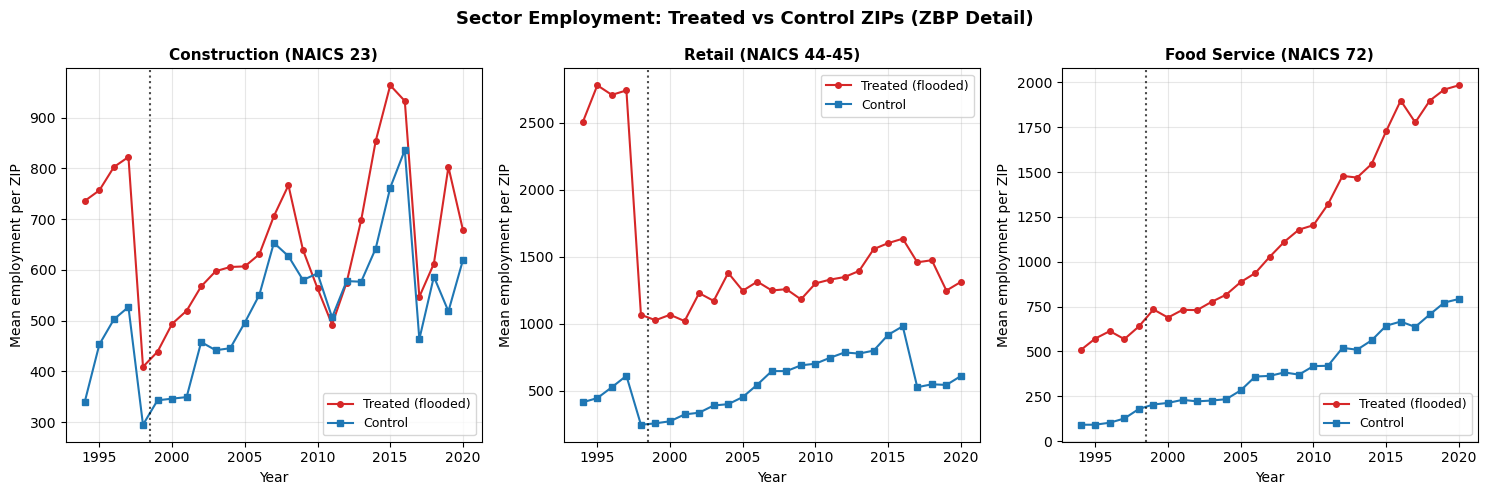

Saved: figures/17_zbp_sector_trajectories.png


In [8]:
traj = panel.groupby(['year', 'treated'])[['construction_emp', 'retail_emp', 'foodservice_emp']].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sector_titles = {
    'construction_emp': 'Construction (NAICS 23)',
    'retail_emp':       'Retail (NAICS 44-45)',
    'foodservice_emp':  'Food Service (NAICS 72)',
}

for ax, (col, title) in zip(axes, sector_titles.items()):
    for grp, color, label, marker in [
        (1, '#d62728', 'Treated (flooded)', 'o'),
        (0, '#1f77b4', 'Control', 's'),
    ]:
        g = traj[traj['treated'] == grp]
        ax.plot(g['year'], g[col], f'{marker}-', color=color, label=label, markersize=4)
    ax.axvline(1998.5, color='black', linestyle=':', alpha=0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mean employment per ZIP')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Sector Employment: Treated vs Control ZIPs (ZBP Detail)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '17_zbp_sector_trajectories.png', dpi=150)
plt.show()
print('Saved: figures/17_zbp_sector_trajectories.png')

## 7. Export Panel

In [9]:
out_cols = [
    'zip', 'year', 'treated', 'intensity', 'nfip_total_paid', 'post',
    # Estimated employment (from size-class midpoints)
    'construction_emp', 'retail_emp', 'foodservice_emp', 'emp_total',
    # Establishment counts (no suppression)
    'construction_estab', 'retail_estab', 'foodservice_estab', 'estab_total',
    # Log outcomes
    'ln_construction', 'ln_retail', 'ln_foodservice',
    'ln_construction_estab', 'ln_retail_estab', 'ln_foodservice_estab',
    # Shares
    'construction_share', 'retail_share', 'foodservice_share',
]
out_cols = [c for c in out_cols if c in panel.columns]

out_path = PROC_DIR / 'did_zbp_sector_panel.csv'
panel[out_cols].sort_values(['zip', 'year']).to_csv(out_path, index=False)

print(f'Exported: {out_path}')
print(f'Shape: {panel[out_cols].shape}')
print(f'ZIPs: {panel["zip"].nunique()} ({panel[panel["treated"]==1]["zip"].nunique()} treated)')
print(f'Years: {panel["year"].min()}–{panel["year"].max()}')
print('\nSample sector data for ZIP 78130 (treated):')
print(panel[panel['zip']=='78130'][['year','construction_emp','retail_emp','foodservice_emp',
                                    'construction_estab','retail_estab','foodservice_estab']].head(10).to_string(index=False))
print('\nNext step: Run R/10_did_zbp_sector.R')

Exported: ../data/processed/panels/did_zbp_sector_panel.csv
Shape: (351, 23)
ZIPs: 13 (4 treated)
Years: 1994–2020

Sample sector data for ZIP 78130 (treated):
 year  construction_emp  retail_emp  foodservice_emp  construction_estab  retail_estab  foodservice_estab
 1994            1222.0      9526.0           1930.0                 156           578                 86
 1995            1148.0     10577.5           2206.5                 168           570                 86
 1996            1299.0     10208.5           2377.5                 180           569                 97
 1997            1322.0     10473.0           2161.0                 188           624                100
 1998             654.5      4051.0           2412.0                  96           251                123
 1999             665.5      3902.5           2767.0                 107           254                119
 2000             781.5      4008.5           2562.5                 100           257            